In [13]:
import matplotlib.pyplot as plt
import networkx as nx

class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
        self.height = 1

def get_height(node):
    if not node:
        return 0
    return node.height

def get_balance(node):
    if not node:
        return 0
    return get_height(node.left) - get_height(node.right)

def right_rotate(y):
    x = y.left
    T2 = x.right

    # Perform rotation
    x.right = y
    y.left = T2

    # Update heights
    y.height = 1 + max(get_height(y.left), get_height(y.right))
    x.height = 1 + max(get_height(x.left), get_height(x.right))

    # Return new root
    return x

def left_rotate(x):
    y = x.right
    T2 = y.left

    #Perform rotation
    y.left = x
    x.right = T2

    # Update heights
    y.height = 1 + max(get_height(y.left), get_height(y.right))
    x.height = 1 + max(get_height(x.left), get_height(x.right))

    # Return new root
    return y

def add(node, key):
    if not node:
        return Node(key)

    if key < node.key:
        node.left = add(node.left, key)
    elif key > node.key:
        node.right = add(node.right, key)
    else:
        return node

    # Update height of this ancestor node
    node.height = 1 + max(get_height(node.left), get_height(node.right))

    balance = get_balance(node)

    #Left Left
    if balance > 1 and key < node.left.key:
        return right_rotate(node)

    #Right Right
    if balance < -1 and key > node.right.key:
      return left_rotate(node)

    # Left Right Case
    if balance > 1 and key > node.left.key:
        node.left = left_rotate(node.left)
        return right_rotate(node)

    # Right Left Case
    if balance < -1 and key < node.right.key:
        node.right = right_rotate(node.right)
        return left_rotate(node)

    return node

def fill_tree(graph, node, depth, levels):
    if not node:
        return

    graph.add_node(node.key)
    levels.setdefault(depth, []).append(node.key)

    if node.left:
        graph.add_edge(node.key, node.left.key)
        fill_tree(graph, node.left, depth + 1, levels)

    if node.right:
        graph.add_edge(node.key, node.right.key)
        fill_tree(graph, node.right, depth + 1, levels)


def hierarchy_layout(graph, root):
    pos = {}
    levels = {}

    fill_tree(graph, root, 0, levels)

    for depth in sorted(levels.keys()):
        nodes_at_level = levels[depth]
        width = len(nodes_at_level)

        for i, node in enumerate(nodes_at_level):
            x = i - width / 2
            y = -depth
            pos[node] = (x, y)
    return pos

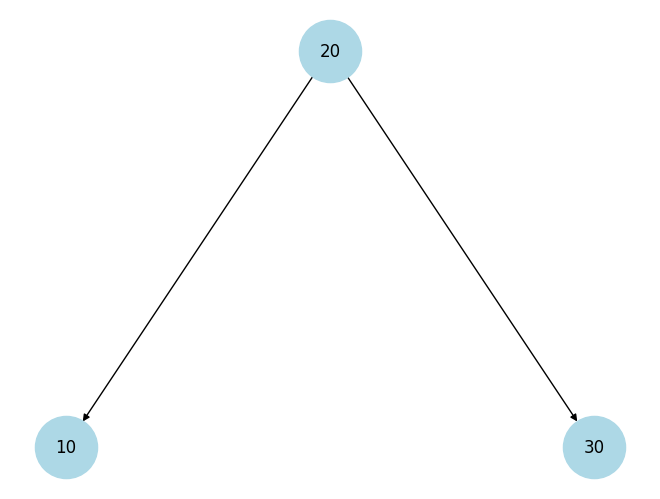

In [18]:
# Driver code
root = None

root = add(root, 30)
root = add(root, 20)
root = add(root, 10)

G = nx.DiGraph()
pos = hierarchy_layout(G, root)

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
plt.show()

# Left Unbalanced Tree
#        30
#       /
#      20
#     /
#    10
# Desired tree
#    20
#   /  \
#  10   30


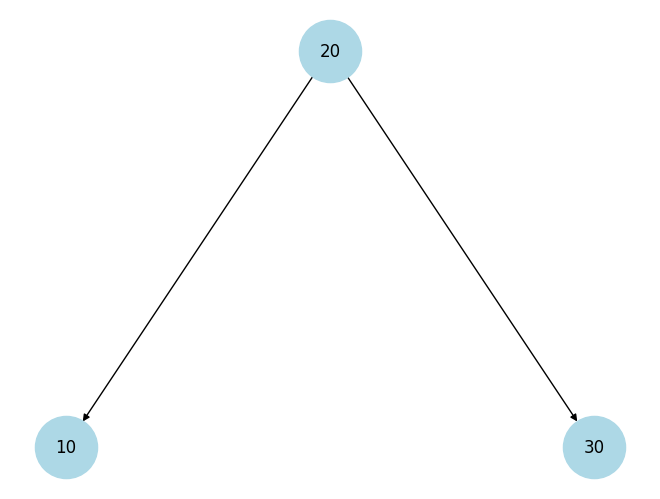

In [16]:
# Driver code
root = None

root = add(root, 10)
root = add(root, 20)
root = add(root, 30)

G = nx.DiGraph()
pos = hierarchy_layout(G, root)

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
plt.show()

# Right Unbalanced Tree
#    10
#      \
#       20
#         \
#          30
# Desired tree
#    20
#   /  \
#  10   30

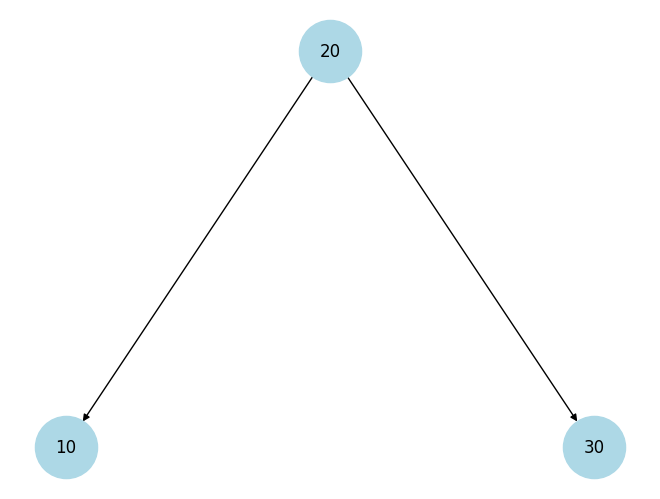

In [19]:
# Driver code
root = None

root = add(root, 30)
root = add(root, 10)
root = add(root, 20)

G = nx.DiGraph()
pos = hierarchy_layout(G, root)

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
plt.show()

# Left-Right Unbalanced Tree
#        30
#       /
#      10
#        \
#         20
# Desired tree
#    20
#   /  \
#  10   30


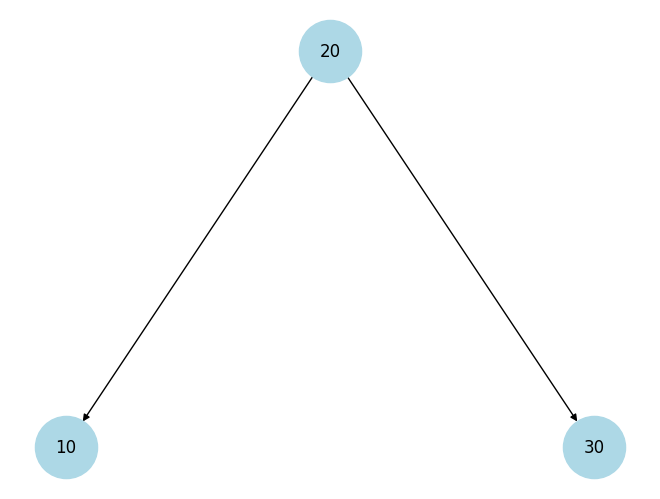

In [20]:
# Driver code
root = None

root = add(root, 10)
root = add(root, 30)
root = add(root, 20)

G = nx.DiGraph()
pos = hierarchy_layout(G, root)

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
plt.show()

# Right-Left Unbalanced Tree
#        10
#         \
#         30
#         /
#        20
# Desired tree
#    20
#   /  \
#  10   30
